Linear Regression using Boston Housing Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", version=1)

In [ ]:
boston.data.shape

(506, 13)

In [ ]:
boston.feature_names

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [ ]:
data = pd.DataFrame(boston.data)
data.columns = boston.feature_names

data.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222.0,18.7,394.12,5.21
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311.0,15.2,395.60,12.43
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311.0,15.2,396.90,19.15
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311.0,15.2,386.63,29.93
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311.0,15.2,386.71,17.10


In [ ]:
# Adding 'Price' (target) column to the data
boston.target.shape

(506,)

In [ ]:
data['Price'] = boston.target
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
data.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  Price    506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [ ]:
# Input Data
x = boston.data.copy()
# Convert categorical columns to numeric (float) as LinearRegression expects numerical input
x['CHAS'] = x['CHAS'].astype(float)
x['RAD'] = x['RAD'].astype(float)

# Output Data
y = boston.target

# splitting data to training and testing dataset.

# from sklearn.cross_validation import train_test_split
# the submodule cross_validation is renamed and deprecated to model_selection
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size =0.2,
                                                    random_state = 0)

print("xtrain shape : ", xtrain.shape)
print("xtest shape  : ", xtest.shape)
print("ytrain shape : ", ytrain.shape)
print("ytest shape  : ", ytest.shape)

xtrain shape :  (404, 13)
xtest shape  :  (102, 13)
ytrain shape :  (404,)
ytest shape  :  (102,)


In [ ]:
xtrain = np.array(xtrain)
xtest = np.array(xtest)

# Fitting Multi Linear regression model to training model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(xtrain, ytrain)

# predicting the test set results
y_pred = regressor.predict(xtest)

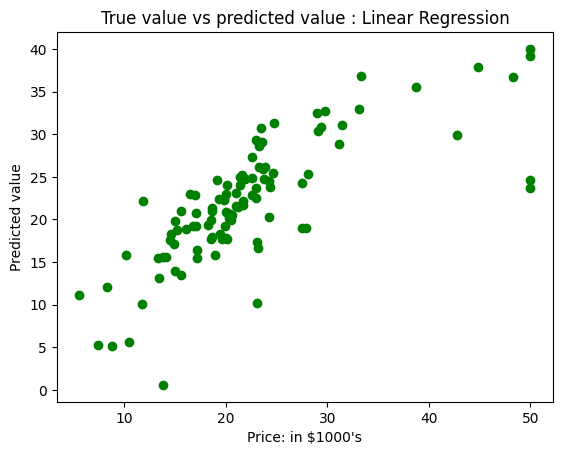

In [ ]:
# Plotting Scatter graph to show the prediction
# results - 'ytrue' value vs 'y_pred' value
plt.scatter(ytest, y_pred, c = 'green')
plt.xlabel("Price: in $1000's")
plt.ylabel("Predicted value")
plt.title("True value vs predicted value : Linear Regression")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mse = mean_squared_error(ytest, y_pred)
mae = mean_absolute_error(ytest,y_pred)
print("Mean Square Error : ", mse)
print("Mean Absolute Error : ", mae)

Mean Square Error :  33.44897999767639
Mean Absolute Error :  3.8429092204444983


 Develop a simple linear regression model, extend it
to multiple linear regression with several variables, and visualize both the regression
line and residual plots

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Generate synthetic data for simple linear regression
np.random.seed(42)
X_simple = np.random.rand(100, 1) * 10 # Feature
y_simple = 3 * X_simple + 7 + np.random.randn(100, 1) * 2 # Target with noise

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=0)

# Build and train the simple linear regression model
simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

# Predict on test data
y_pred_simple = simple_lr.predict(X_test)

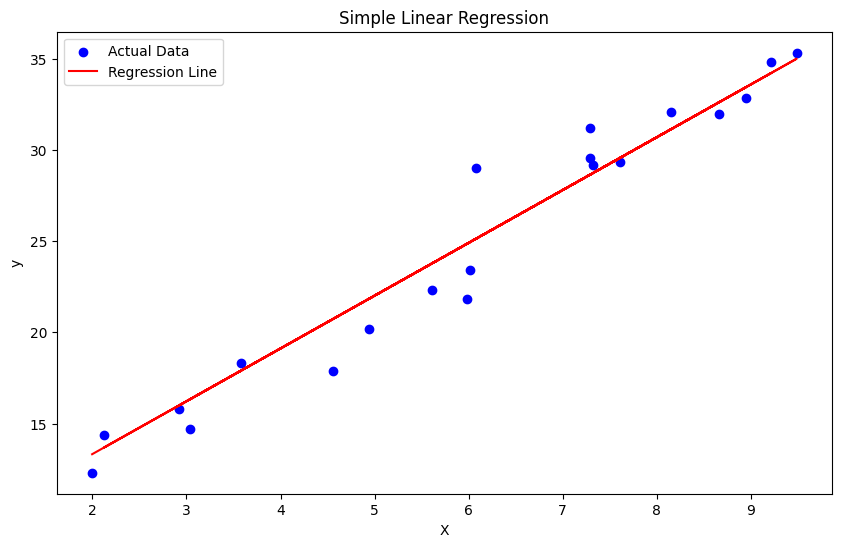

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred_simple, color='red', label='Regression Line')
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

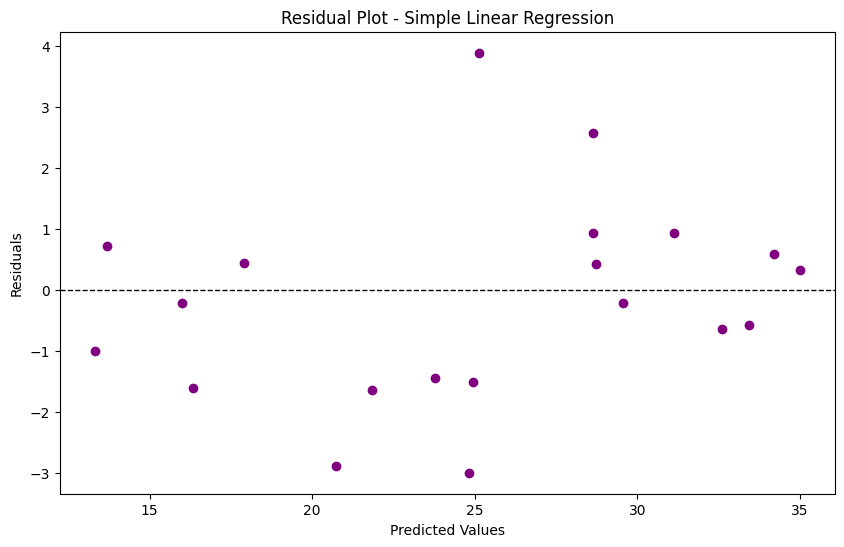

In [ ]:

residuals_simple = y_test - y_pred_simple
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_simple, residuals_simple, color='purple')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Simple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [ ]:
np.random.seed(42)
X_multi = np.random.rand(100, 3) * 10 # 3 features
y_multi = 4 * X_multi[:, 0] + 3 * X_multi[:, 1] - 2 * X_multi[:, 2] + 5 + np.random.random(100)

# Split the data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi)

# Build and train the multiple linear regression model
multi_lr = LinearRegression()
multi_lr.fit(X_train_multi, y_train_multi)

# Predict on test data
y_pred_multi = multi_lr.predict(X_test_multi)

In [ ]:
# Choose one feature to plot (e.g., Feature 0)
feature_index = 0 # Index of the feature to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values

# Generate values for the selected feature
x_values = np.linspace(X_test_multi[:, feature_index].min(), X_test_multi[:, feature_index].max(), 100)

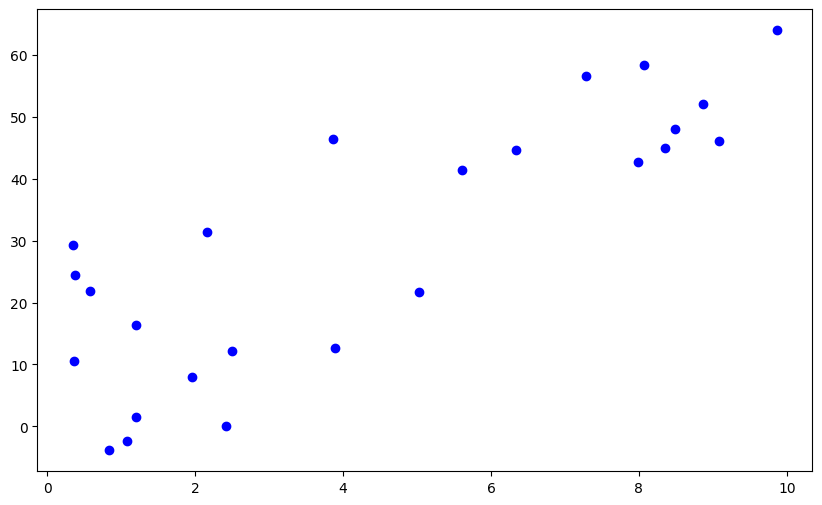

In [ ]:
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x_values.shape[0], 1)) # Copy fixed features
X_plot[:, feature_index] = x_values # Replace the selected feature with varying value

# Predict using the model
y_plot = multi_lr.predict(X_plot)

# Scatter plot of actual data points for the selected feature
plt.figure(figsize=(10, 6))
plt.scatter(X_test_multi[:, feature_index], y_test_multi, color='blue', label='Actual Data')

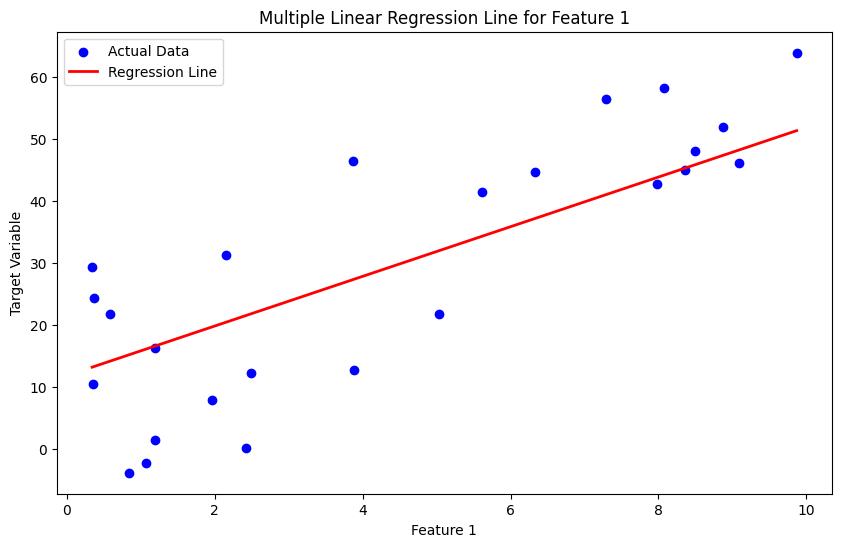

In [ ]:
# Scatter plot of actual data points for the selected feature
plt.figure(figsize=(10, 6))
plt.scatter(X_test_multi[:, feature_index], y_test_multi, color='blue', label='Actual Data')

# Plot the regression line
plt.plot(x_values, y_plot, color='red', label='Regression Line', linewidth=2)

# Add labels and title
plt.title(f'Multiple Linear Regression Line for Feature {feature_index + 1}')
plt.xlabel(f'Feature {feature_index + 1}')
plt.ylabel('Target Variable')
plt.legend()
plt.show()

In [ ]:
# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x_values.shape[0], 1)) # Copy fixed features
X_plot[:, feature_index] = x_values # Replace the selected feature with varying value

# Predict using the model
y_plot = multi_lr.predict(X_plot)

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Choose two features to plot (e.g., Features 0 and 1)
feature_indices = [0, 1] # Indices of the features to visualize
fixed_features = np.mean(X_test_multi, axis=0) # Fix other features at their mean values

# Generate a grid of values for the selected features
x1_values = np.linspace(X_test_multi[:, feature_indices[0]].min(), X_test_multi[:, feature_indices[0]].max())
x2_values = np.linspace(X_test_multi[:, feature_indices[1]].min(), X_test_multi[:, feature_indices[1]].max())
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)

In [ ]:

# Create data points for predictions by fixing other features
X_plot = np.tile(fixed_features, (x1_grid.size, 1)) # Copy fixed features
X_plot[:, feature_indices[0]] = x1_grid.ravel() # Replace feature 1
X_plot[:, feature_indices[1]] = x2_grid.ravel() # Replace feature 2

# Predict using the model
y_plot = multi_lr.predict(X_plot).reshape(x1_grid.shape)

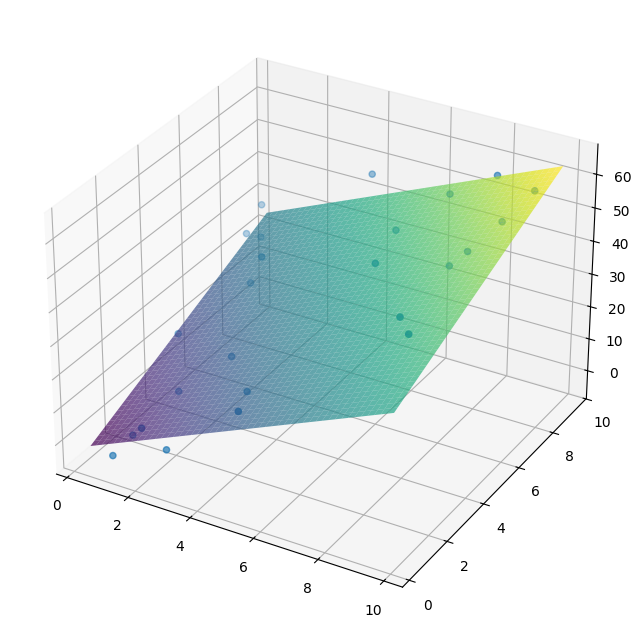

In [ ]:
# Create a 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x1_grid, x2_grid, y_plot, cmap='viridis', alpha=0.7)

# Scatter the actual data points
ax.scatter(X_test_multi[:, feature_indices[0]], X_test_multi[:, feature_indices[1]], y_test_multi)

/tmp/ipykernel_389/54775864.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


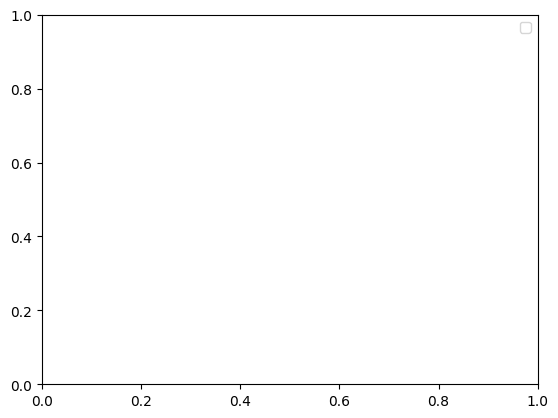

In [ ]:

# Add labels and title
ax.set_title('Multiple Linear Regression Hyperplane')
ax.set_xlabel(f'Feature {feature_indices[0] + 1}')
ax.set_ylabel(f'Feature {feature_indices[1] + 1}')
ax.set_zlabel('Target Variable')
plt.legend()
plt.show()

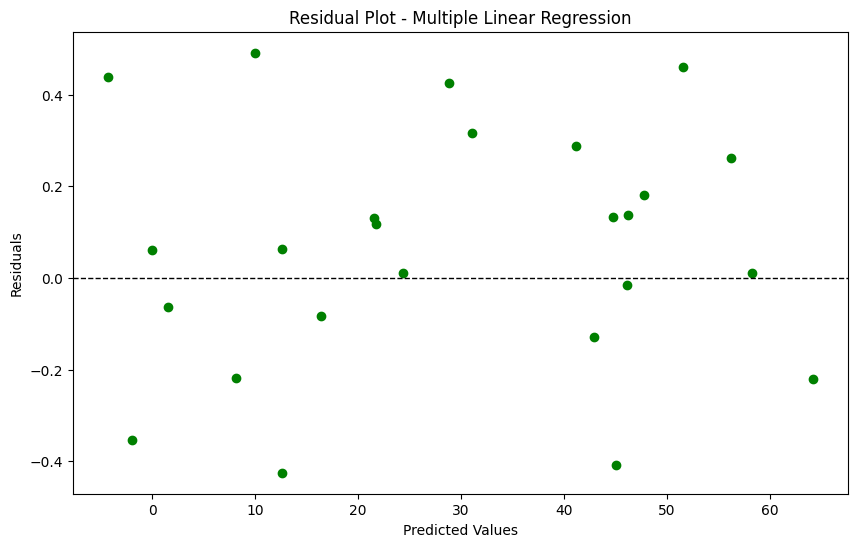

In [ ]:
residuals_multi = y_test_multi - y_pred_multi
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuals_multi, color='green')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot - Multiple Linear Regression')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

In [ ]:
print("Simple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_simple):.2f}")
print(f"R2 Score: {r2_score(y_test, y_pred_simple):.2f}\n")
print("Multiple Linear Regression Metrics:")
print(f"Mean Squared Error: {mean_squared_error(y_test_multi, y_pred_multi):.2f}")
print(f"R2 Score: {r2_score(y_test_multi, y_pred_multi):.2f}")

Simple Linear Regression Metrics:
Mean Squared Error: 2.68
R2 Score: 0.95

Multiple Linear Regression Metrics:
Mean Squared Error: 0.07
R2 Score: 1.00
